In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('optimal_ranges_combo.csv')
df = df.set_index('Unnamed: 0')

labels = df.columns.tolist()
df = df.loc[labels, labels]  

data = df.fillna('').values.tolist()

In [4]:
def get_range_width(cell):
    try:
        nums = eval(cell)
        return nums[1] - nums[0]
    except:
        return np.nan

In [5]:
value_matrix = np.array([
    [get_range_width(cell) for cell in row]
    for row in data
])

/var/folders/85/rzkn78t10p72g2_nfq5ytx3w0000gn/T/ipykernel_95139/4252257643.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((i-.5, i-.5), 1, 1, fill=True, color='midnightblue', edgecolor='black'))


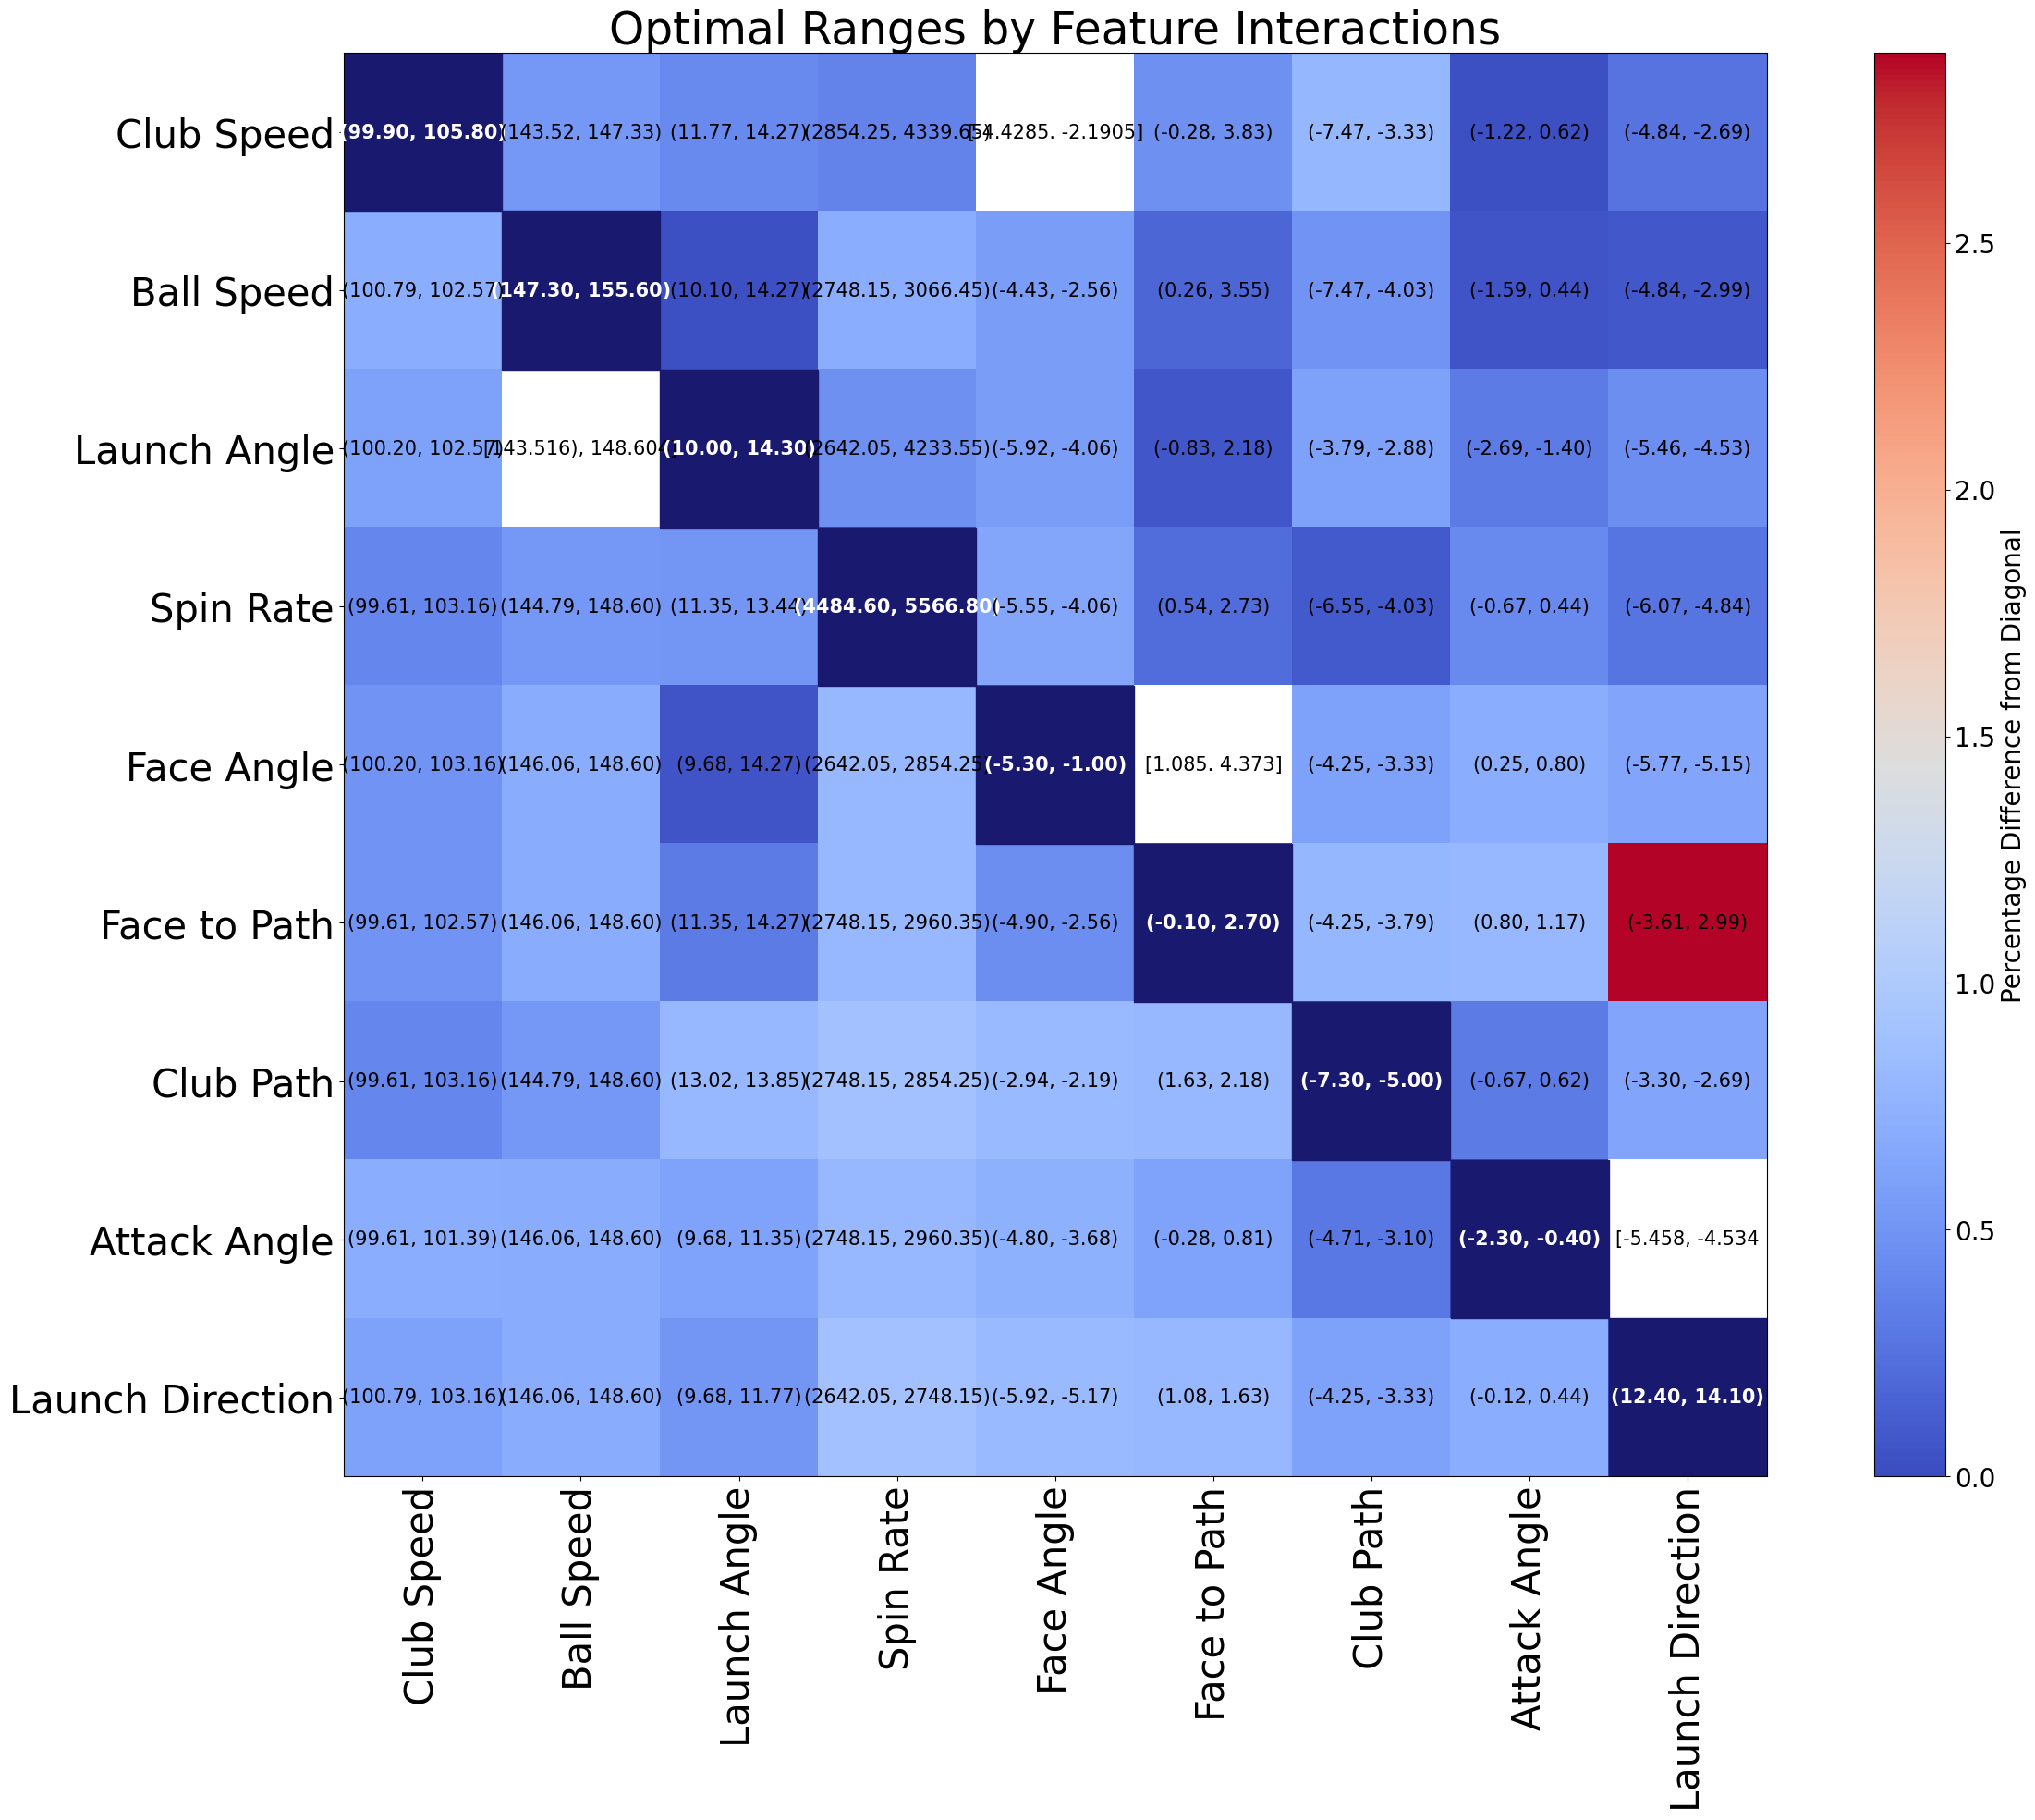

In [ ]:
fig, ax = plt.subplots(figsize=(30, 20))
diag = np.diag(value_matrix)
diff_from_diag = np.abs(value_matrix - diag[np.newaxis, :])
percent_diff = np.abs(value_matrix - diag[np.newaxis, :]) / np.abs(diag[np.newaxis, :])

masked_array = np.ma.masked_invalid(percent_diff)

c = ax.imshow(masked_array, cmap='coolwarm')

for i in range(len(labels)):
    for j in range(len(labels)):
        if data[i][j] != '':
            if i == j:
                try:
                    nums = eval(data[i][j])
                    rounded_text = f'({nums[0]:.2f}, {nums[1]:.2f})'
                except:
                    rounded_text = data[i][j]
                ax.text(j, i, rounded_text, ha='center', va='center', color='white', fontsize=15, weight='bold')

                ax.add_patch(plt.Rectangle((i-.5, i-.5), 1, 1, fill=True, color='midnightblue', edgecolor='black'))
            else:
                try:
                    nums = eval(data[i][j])
                    rounded_text = f'({nums[0]:.2f}, {nums[1]:.2f})'
                except:
                    rounded_text = data[i][j]
                ax.text(j, i, rounded_text, ha='center', va='center', fontsize=15)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=30, rotation = 90)
ax.set_yticklabels(labels, fontsize=30)
plt.title('Optimal Ranges by Feature Interactions', fontsize=35)
cbar = fig.colorbar(c, ax=ax)
cbar.ax.tick_params(labelsize=20)  
cbar.set_label('Percentage Difference from Diagonal', fontsize = 20)  
plt.show()

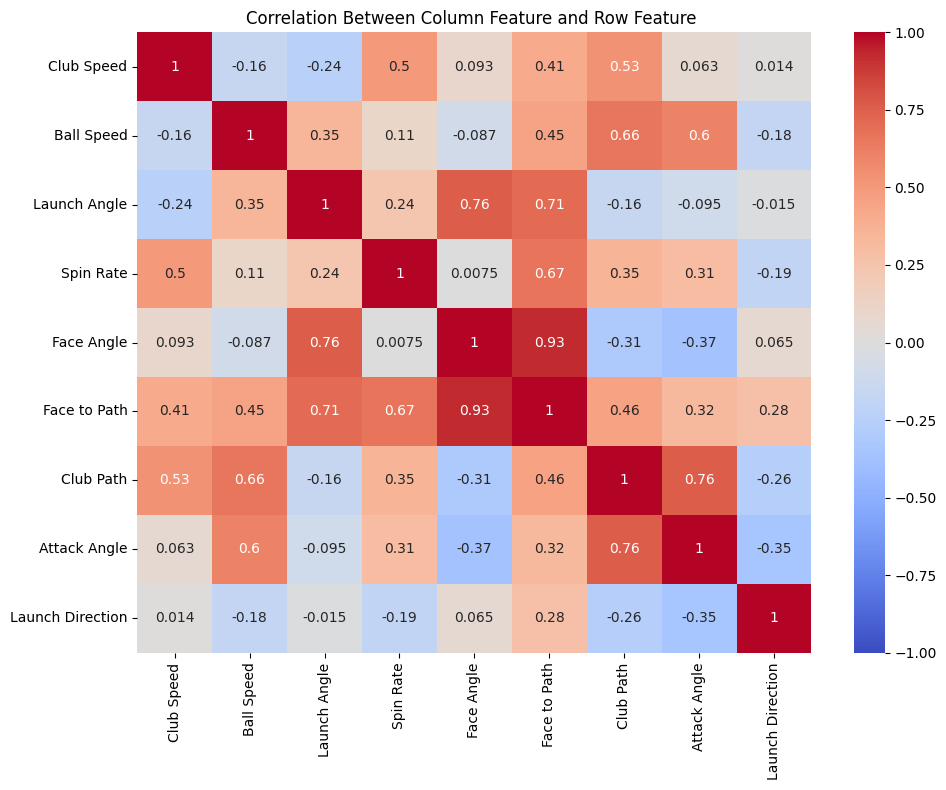

In [ ]:
features = [
    'Club Speed', 'Ball Speed', 'Launch Angle', 'Spin Rate', 'Face Angle',
    'Face to Path', 'Club Path', 'Attack Angle', 'Launch Direction'
]

df = pd.DataFrame(value_matrix, index=features, columns=features)
correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Column Feature and Row Feature')
plt.tight_layout()
plt.savefig('CorrMatrix.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()